# Multilingual Health QA: Hybrid Retrieval with Experiment Suite

Approach: for each test question, retrieve the closest training question within the same
language subset using a blend of TF-IDF and multilingual sentence embeddings, then return that
training answer. No GPU fine-tuning is needed, so it runs in minutes.

Scoring (Zindi): weighted mean of ROUGE-1 F1 (0.37), ROUGE-L F1 (0.37), LLM-as-a-Judge (0.26).
The submission writes the same predicted answer into all three Target columns.

This notebook runs 12 tracked experiments. Each one fits on the training split, scores on
validation, writes a Zindi submission file, and appends a row to an experiment log.
After you upload each submission to Zindi, paste the public score into the log so your results
table is complete.

Integrity reminder: read each cell until you can explain it, and disclose AI assistance as the
brief requires. You may be asked to defend any part of this in an oral viva.


In [31]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Install dependencies

In [1]:
!pip -q install sentence-transformers rouge-score scikit-learn pandas numpy tqdm
print("Dependencies installed.")

  Preparing metadata (setup.py) ... done
Dependencies installed.


## 2. Data source and working folders

The CSVs are read straight from the project's GitHub repo, so there is nothing to upload. Cache, submissions and figures go in a local working folder.

In [2]:
import os

# Pull the data straight from the project repo, so there is nothing to upload.
DATA_URL = 'https://raw.githubusercontent.com/Nick-Lemy/multilingual-health-qa/main/data'

# Local working folders for cache, submissions and figures.
WORK_DIR  = 'health-qa'
CACHE_DIR = os.path.join(WORK_DIR, 'cache')
SUB_DIR   = os.path.join(WORK_DIR, 'submissions')
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(SUB_DIR, exist_ok=True)
print("Reading data from", DATA_URL)

Reading data from https://raw.githubusercontent.com/Nick-Lemy/multilingual-health-qa/main/data


## 3. Imports, seed, model choices

In [3]:
import random, hashlib, json, re, datetime
import numpy as np
import pandas as pd
from collections import Counter
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED)

# Primary embedding model (stronger cross-lingual matching than MiniLM).
PRIMARY_MODEL = 'sentence-transformers/paraphrase-multilingual-mpnet-base-v2'
# Alternate model used in one experiment to compare embedding backbones.
ALT_MODEL     = 'sentence-transformers/LaBSE'

print("Primary:", PRIMARY_MODEL)
print("Alternate:", ALT_MODEL)

Primary: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Alternate: sentence-transformers/LaBSE


## 4. Load data and inspect columns

Check the printout, then confirm the column mapping in the next cell.

In [4]:
def load(name):
    try:
        return pd.read_csv(f'{DATA_URL}/{name}')
    except Exception:
        return None

train = load('Train.csv')
val   = load('Val.csv')
test  = load('Test.csv')
samp  = load('SampleSubmission.csv')

assert train is not None, "Train.csv not found"
assert test  is not None, "Test.csv not found"
assert samp  is not None, "SampleSubmission.csv not found"

for nm, df in [('Train', train), ('Val', val), ('Test', test), ('SampleSubmission', samp)]:
    if df is not None:
        print(f"\n{nm} shape={df.shape}")
        print("columns:", list(df.columns))
        print(df.head(2).to_string())


Train shape=(29815, 4)
columns: ['ID', 'input', 'output', 'subset']
                       ID                                                                                                                                                                                                                                                                   input                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

## 5. Column mapping

Auto-detection guesses the columns. Verify and override below if any guess is wrong.

In [5]:
def guess(cols, *keys):
    for k in keys:
        for c in cols:
            if k in c.lower():
                return c
    return None

cols = list(train.columns)
ID_COL       = guess(cols, 'id') or 'ID'
QUESTION_COL = guess(cols, 'input', 'question', 'query', 'text', 'prompt')
ANSWER_COL   = guess(cols, 'output', 'answer', 'response', 'target', 'reply')
LANG_COL     = guess(cols, 'subset', 'language', 'lang', 'country', 'locale')

# Override here if needed:
# ID_COL = 'ID'
# QUESTION_COL = 'question_text'
# ANSWER_COL = 'answer_text'
# LANG_COL = 'language'

print("ID_COL      =", ID_COL)
print("QUESTION_COL=", QUESTION_COL)
print("ANSWER_COL  =", ANSWER_COL)
print("LANG_COL    =", LANG_COL)
assert QUESTION_COL in train.columns and ANSWER_COL in train.columns
assert QUESTION_COL in test.columns
print("Submission columns:", list(samp.columns))

ID_COL      = ID
QUESTION_COL= input
ANSWER_COL  = output
LANG_COL    = subset
Submission columns: ['ID', 'TargetRLF1', 'TargetR1F1', 'TargetLLM']


## 6. Preprocess and build the validation split

Light normalization only, to avoid damaging non-Latin scripts. If Val.csv is absent we carve a
language-stratified split from Train for tuning.

In [6]:
def norm(s):
    s = '' if pd.isna(s) else str(s)
    return re.sub(r'\s+', ' ', s.strip())

frames = [train, test] + ([val] if val is not None else [])
for df in frames:
    df[QUESTION_COL] = df[QUESTION_COL].map(norm)
train[ANSWER_COL] = train[ANSWER_COL].map(norm)
if val is not None and ANSWER_COL in val.columns:
    val[ANSWER_COL] = val[ANSWER_COL].map(norm)

def lang_series(df):
    if LANG_COL and LANG_COL in df.columns:
        return df[LANG_COL].astype(str)
    return pd.Series(['all'] * len(df), index=df.index)

train['_lang'] = lang_series(train)
test['_lang']  = lang_series(test)

if val is None:
    from sklearn.model_selection import train_test_split
    strat = train['_lang'] if train['_lang'].nunique() > 1 else None
    tr_idx, va_idx = train_test_split(train.index, test_size=0.15,
                                      random_state=SEED, stratify=strat)
    val = train.loc[va_idx].copy()
    train_fit = train.loc[tr_idx].copy()
else:
    val['_lang'] = lang_series(val)
    train_fit = train.copy()

train_fit = train_fit.reset_index(drop=True)
val = val.reset_index(drop=True)
test = test.reset_index(drop=True)
print("train_fit:", train_fit.shape, "val:", val.shape, "test:", test.shape)
print("languages:", sorted(train_fit['_lang'].unique()))

train_fit: (29815, 5) val: (6686, 5) test: (2618, 4)
languages: ['Aka_Gha', 'Amh_Eth', 'Eng_Eth', 'Eng_Gha', 'Eng_Ken', 'Eng_Uga', 'Lug_Uga', 'Swa_Ken']


## 6b. Exploratory data analysis

Figures are saved to a local `figures` folder so you can drop them straight into the report.
After running, write two or three sentences of interpretation under each plot in your report
(for example, which languages are under-represented, and how much the test set overlaps the
training set, which directly explains why retrieval works here).

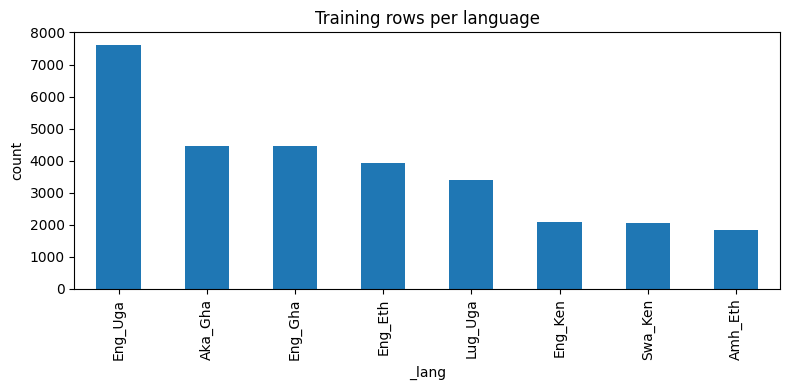

_lang
Eng_Uga    7624
Aka_Gha    4455
Eng_Gha    4443
Eng_Eth    3915
Lug_Uga    3383
Eng_Ken    2080
Swa_Ken    2070
Amh_Eth    1845
Name: count, dtype: int64


In [7]:
import matplotlib.pyplot as plt
FIG_DIR = os.path.join(WORK_DIR, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

# Language distribution
lc = train['_lang'].value_counts()
plt.figure(figsize=(8,4)); lc.plot(kind='bar')
plt.title('Training rows per language'); plt.ylabel('count'); plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'lang_distribution.png'), dpi=120); plt.show()
print(lc)

         _qlen    _alen
count  29815.0  29815.0
mean      15.1     76.2
std        9.1     58.9
min        0.0      1.0
25%        9.0     30.0
50%       13.0     61.0
75%       18.0    107.0
max       83.0    482.0


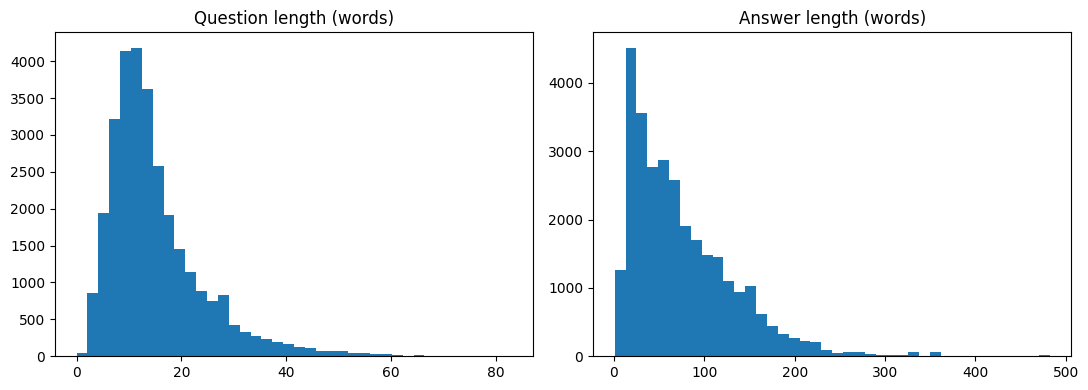


Median answer length by language:
_lang
Aka_Gha    100.0
Eng_Uga     73.0
Eng_Gha     70.0
Lug_Uga     68.0
Swa_Ken     66.0
Eng_Ken     64.0
Eng_Eth     24.0
Amh_Eth     19.0
Name: _alen, dtype: float64


In [8]:
# Question and answer length distributions
train['_qlen'] = train[QUESTION_COL].str.split().apply(len)
train['_alen'] = train[ANSWER_COL].str.split().apply(len)
print(train[['_qlen', '_alen']].describe().round(1))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(train['_qlen'], bins=40); ax[0].set_title('Question length (words)')
ax[1].hist(train['_alen'], bins=40); ax[1].set_title('Answer length (words)')
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, 'length_distribution.png'), dpi=120); plt.show()

# Per-language answer length summary
print('\nMedian answer length by language:')
print(train.groupby('_lang')['_alen'].median().sort_values(ascending=False))

In [9]:
# Duplicates and missing values
print('Duplicate questions in train:', int(train[QUESTION_COL].duplicated().sum()))
print('Duplicate answers in train  :', int(train[ANSWER_COL].duplicated().sum()))
print('\nMissing values per column:')
print(train.isna().sum())

Duplicate questions in train: 1482
Duplicate answers in train  : 11750

Missing values per column:
ID        0
input     0
output    0
subset    0
_lang     0
_qlen     0
_alen     0
dtype: int64


Fraction of TEST questions appearing verbatim in TRAIN, by language:
Aka_Gha    0.0%
Amh_Eth    0.0%
Eng_Eth    0.0%
Eng_Gha    0.0%
Eng_Ken    0.0%
Eng_Uga    0.0%
Lug_Uga    0.0%
Swa_Ken    0.0%
dtype: object


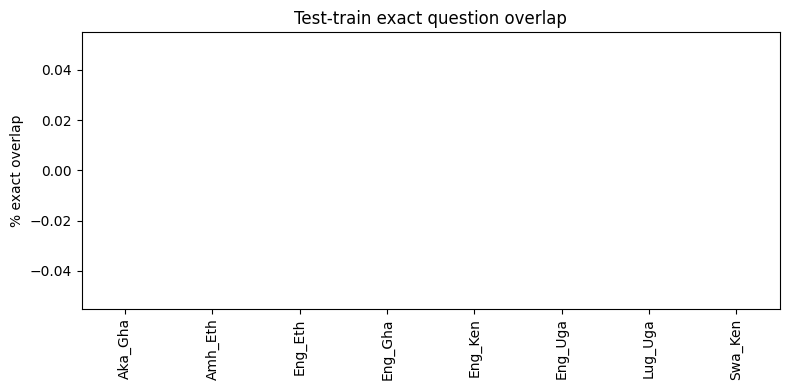

In [10]:
# Test-train exact question overlap, per language.
# This is the key EDA for a retrieval approach: it sets the ceiling on how well
# returning a stored training answer can score.
overlap = {}
for lg in test['_lang'].unique():
    tr_q = set(train.loc[train['_lang'] == lg, QUESTION_COL])
    te_q = test.loc[test['_lang'] == lg, QUESTION_COL]
    if len(te_q):
        overlap[lg] = te_q.isin(tr_q).mean()
ov = pd.Series(overlap).sort_values(ascending=False)
print('Fraction of TEST questions appearing verbatim in TRAIN, by language:')
print((ov * 100).round(1).astype(str) + '%')

plt.figure(figsize=(8,4)); (ov * 100).plot(kind='bar')
plt.ylabel('% exact overlap'); plt.title('Test-train exact question overlap')
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, 'test_train_overlap.png'), dpi=120); plt.show()

## 7. Embedding helper (cached)

Embeddings are cached by model and data fingerprint, so reruns reuse them. The model objects are
also cached in memory across experiments.

In [11]:
from sentence_transformers import SentenceTransformer
import torch

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device:", DEVICE)
_model_cache = {}

def get_model(name):
    if name not in _model_cache:
        _model_cache[name] = SentenceTransformer(name, device=DEVICE)
    return _model_cache[name]

def _fp(name, texts):
    h = hashlib.md5(); h.update(name.encode()); h.update(str(len(texts)).encode())
    for t in texts[:50]:
        h.update(t.encode('utf-8', 'ignore'))
    return h.hexdigest()[:12]

def get_emb(name, texts, tag):
    texts = list(texts)
    path = os.path.join(CACHE_DIR, f'emb_{tag}_{_fp(name, texts)}.npy')
    if os.path.exists(path):
        return np.load(path)
    emb = get_model(name).encode(texts, batch_size=64, show_progress_bar=True,
                                 convert_to_numpy=True, normalize_embeddings=True)
    np.save(path, emb)
    return emb

print("Embedding helper ready.")

Device: cuda
Embedding helper ready.


## 8. Flexible retriever and per-language router

One retriever per language subset. It supports a TF-IDF and semantic blend, an exact-match
shortcut, and three answer-selection strategies (single best, top-k majority vote, top-k centroid).

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

class LangRetriever:
    def __init__(self, alpha=0.5, analyzer='word', ngram=(1,2),
                 exact_match=True, fusion='best', topk=3):
        self.alpha = alpha
        self.exact_match = exact_match
        self.fusion = fusion
        self.topk = topk
        self.vec = TfidfVectorizer(ngram_range=ngram, analyzer=analyzer, min_df=1)

    def fit(self, questions, answers, q_emb, a_emb=None):
        self.questions = list(questions)
        self.answers   = list(answers)
        self.q_emb     = q_emb
        self.a_emb     = a_emb
        self.tfidf     = self.vec.fit_transform(self.questions)
        self.exact     = {q: a for q, a in zip(self.questions, self.answers)}

    def _combined_sim(self, queries, query_emb):
        q_tfidf = self.vec.transform(queries)
        tfidf_sim = cosine_similarity(q_tfidf, self.tfidf)
        sem_sim   = query_emb @ self.q_emb.T
        return self.alpha * sem_sim + (1 - self.alpha) * tfidf_sim

    def predict(self, queries, query_emb):
        sim = self._combined_sim(queries, query_emb)
        k = min(self.topk, sim.shape[1])
        out = []
        for i, qi in enumerate(queries):
            if self.exact_match and qi in self.exact:
                out.append(self.exact[qi]); continue
            order = np.argsort(-sim[i])[:k]
            if self.fusion == 'best':
                out.append(self.answers[order[0]])
            elif self.fusion == 'majority':
                cand = [self.answers[j] for j in order]
                out.append(Counter(cand).most_common(1)[0][0])
            elif self.fusion == 'centroid' and self.a_emb is not None:
                ae = self.a_emb[order]                  # (k, d)
                centro = ae @ ae.T                      # pairwise sim
                pick = order[int(centro.mean(axis=1).argmax())]
                out.append(self.answers[pick])
            else:
                out.append(self.answers[order[0]])
        return out

def build_router(df, q_emb, a_emb=None, alpha=0.5, per_lang_alpha=None, **kw):
    retr = {}
    for lg in df['_lang'].unique():
        m = (df['_lang'] == lg).values
        a = (per_lang_alpha or {}).get(lg, alpha)
        r = LangRetriever(alpha=a, **kw)
        r.fit(df.loc[m, QUESTION_COL].tolist(),
              df.loc[m, ANSWER_COL].tolist(),
              q_emb[m], None if a_emb is None else a_emb[m])
        retr[lg] = r
    return retr

def route_predict(retr, df, q_emb, fallback_alpha=0.5):
    preds = [''] * len(df)
    for lg in df['_lang'].unique():
        m = (df['_lang'] == lg).values
        idxs = np.where(m)[0]
        if lg in retr:
            r = retr[lg]
        else:
            r = next(iter(retr.values()))   # fallback to any retriever
        p = r.predict(df.loc[m, QUESTION_COL].tolist(), q_emb[m])
        for j, ans in zip(idxs, p):
            preds[j] = ans
    return preds

print("Retriever and router ready.")

Retriever and router ready.


## 9. ROUGE evaluation and experiment logger

In [13]:
from rouge_score import rouge_scorer
_scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=False)

def rouge_eval(preds, refs):
    r1 = rl = 0.0
    for p, r in zip(preds, refs):
        sc = _scorer.score(r, p)
        r1 += sc['rouge1'].fmeasure
        rl += sc['rougeL'].fmeasure
    n = max(len(preds), 1)
    return r1/n, rl/n

LOG_PATH = os.path.join(WORK_DIR, 'experiment_log.csv')

def make_submission(test_preds, exp_id):
    sub = samp.copy()
    sid = ID_COL if ID_COL in sub.columns else sub.columns[0]
    pred_map = dict(zip(test[ID_COL], test_preds))
    answers = sub[sid].map(pred_map).fillna('')
    for c in [c for c in sub.columns if c != sid]:
        sub[c] = answers
    path = os.path.join(SUB_DIR, f'submission_{exp_id}.csv')
    sub.to_csv(path, index=False)
    return path

def log_experiment(exp_id, desc, r1, rl, sub_path, extra=''):
    row = {'exp_id': exp_id, 'description': desc,
           'val_rouge1': round(r1, 4), 'val_rougeL': round(rl, 4),
           'val_rouge_blend': round(0.37*r1 + 0.37*rl, 4),
           'submission_file': os.path.basename(sub_path),
           'public_score': '', 'config': extra,
           'timestamp': datetime.datetime.now().strftime('%Y%m%d_%H%M')}
    if os.path.exists(LOG_PATH):
        log = pd.concat([pd.read_csv(LOG_PATH), pd.DataFrame([row])], ignore_index=True)
    else:
        log = pd.DataFrame([row])
    log.to_csv(LOG_PATH, index=False)
    return row

print("Evaluator and logger ready.")

Evaluator and logger ready.


## 10. Experiment runner

Each experiment fits on train_fit, scores on val, writes a submission, and logs a row. Set
`final=True` to refit on the full labeled data (train_fit plus val) before predicting test.

In [14]:
# pre-compute primary-model embeddings once
emb_p_trainfit = get_emb(PRIMARY_MODEL, train_fit[QUESTION_COL].tolist(), 'p_trainfit')
emb_p_val      = get_emb(PRIMARY_MODEL, val[QUESTION_COL].tolist(),       'p_val')
emb_p_test     = get_emb(PRIMARY_MODEL, test[QUESTION_COL].tolist(),      'p_test')

def run_experiment(exp_id, desc, *, model=PRIMARY_MODEL, alpha=0.5, per_lang_alpha=None,
                   analyzer='word', ngram=(1,2), exact_match=True, fusion='best', topk=3,
                   length_cal=False, final=False, verbose=True):
    # pick embeddings for the chosen model
    if model == PRIMARY_MODEL:
        e_tr, e_va, e_te = emb_p_trainfit, emb_p_val, emb_p_test
    else:
        e_tr = get_emb(model, train_fit[QUESTION_COL].tolist(), 'a_trainfit')
        e_va = get_emb(model, val[QUESTION_COL].tolist(),       'a_val')
        e_te = get_emb(model, test[QUESTION_COL].tolist(),      'a_test')

    a_emb = get_emb(model, train_fit[ANSWER_COL].tolist(), 'ans_trainfit') if fusion == 'centroid' else None

    kw = dict(analyzer=analyzer, ngram=ngram, exact_match=exact_match, fusion=fusion, topk=topk)
    retr = build_router(train_fit, e_tr, a_emb=a_emb, alpha=alpha,
                         per_lang_alpha=per_lang_alpha, **kw)

    val_preds = route_predict(retr, val, e_va)
    if length_cal and ANSWER_COL in val.columns:
        cap = int(np.percentile([len(a.split()) for a in val[ANSWER_COL]], 90))
        val_preds = [' '.join(p.split()[:cap]) for p in val_preds]
    r1, rl = rouge_eval(val_preds, val[ANSWER_COL].tolist()) if ANSWER_COL in val.columns else (0,0)

    # test prediction (refit on full data if final)
    if final and ANSWER_COL in val.columns:
        full = pd.concat([train_fit, val], ignore_index=True)
        full['_lang'] = lang_series(full)
        e_full = get_emb(model, full[QUESTION_COL].tolist(), 'full' if model==PRIMARY_MODEL else 'a_full')
        a_full = get_emb(model, full[ANSWER_COL].tolist(), 'ans_full') if fusion=='centroid' else None
        retr = build_router(full, e_full, a_emb=a_full, alpha=alpha,
                            per_lang_alpha=per_lang_alpha, **kw)
    test_preds = route_predict(retr, test, e_te)
    if length_cal and ANSWER_COL in val.columns:
        test_preds = [' '.join(p.split()[:cap]) for p in test_preds]

    sub_path = make_submission(test_preds, exp_id)
    cfg = json.dumps({'model': model.split('/')[-1], 'alpha': alpha,
                      'per_lang': bool(per_lang_alpha), 'analyzer': analyzer,
                      'ngram': list(ngram), 'exact': exact_match,
                      'fusion': fusion, 'topk': topk, 'len_cal': length_cal})
    log_experiment(exp_id, desc, r1, rl, sub_path, cfg)
    if verbose:
        print(f"[{exp_id}] {desc}")
        print(f"   val ROUGE-1={r1:.4f}  ROUGE-L={rl:.4f}  blend={0.37*r1+0.37*rl:.4f}")
        print(f"   submission: {os.path.basename(sub_path)}")
    return r1, rl

print("Runner ready.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/5.12k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/466 [00:00<?, ?it/s]

Batches:   0%|          | 0/105 [00:00<?, ?it/s]

Batches:   0%|          | 0/41 [00:00<?, ?it/s]

Runner ready.


## 11. Experiments

Run these in order. Record the Zindi public score in the log after uploading each submission.

### Experiment 01: TF-IDF word n-grams baseline

What changed: Pure lexical retrieval, alpha=0 (no semantic component), word unigrams and bigrams.

Why: Establishes a simple lexical floor to measure every later change against.

Outcome (fill after running): ____   Zindi public score: ____   Insight: ____

In [15]:
run_experiment('E01', 'TF-IDF word n-grams baseline', alpha=0.0, analyzer='word', ngram=(1,2))

[E01] TF-IDF word n-grams baseline
   val ROUGE-1=0.4264  ROUGE-L=0.3509  blend=0.2876
   submission: submission_E01.csv


(0.42643756951840533, 0.3509396353540695)

### Experiment 02: TF-IDF character n-grams

What changed: Lexical retrieval using character n-grams (2 to 5) instead of word tokens.

Why: Character features handle morphology and spelling variation in non-Latin scripts better.

Outcome (fill after running): ____   Zindi public score: ____   Insight: ____

In [16]:
run_experiment('E02', 'TF-IDF char n-grams', alpha=0.0, analyzer='char_wb', ngram=(2,5))

[E02] TF-IDF char n-grams
   val ROUGE-1=0.4621  ROUGE-L=0.3888  blend=0.3148
   submission: submission_E02.csv


(0.4620709634516157, 0.3887634673313851)

### Experiment 03: Semantic embeddings only

What changed: Retrieval using only multilingual sentence-embedding similarity, alpha=1.

Why: Tests whether meaning-based matching beats surface overlap on its own.

Outcome (fill after running): ____   Zindi public score: ____   Insight: ____

In [17]:
run_experiment('E03', 'Semantic only', alpha=1.0)

[E03] Semantic only
   val ROUGE-1=0.4704  ROUGE-L=0.3992  blend=0.3218
   submission: submission_E03.csv


(0.4704417853538404, 0.39923728938497033)

### Experiment 04: Hybrid 50/50

What changed: Equal blend of TF-IDF and semantic similarity.

Why: Combines lexical precision with semantic recall to see if the two are complementary.

Outcome (fill after running): ____   Zindi public score: ____   Insight: ____

In [18]:
run_experiment('E04', 'Hybrid 50/50', alpha=0.5)

[E04] Hybrid 50/50
   val ROUGE-1=0.4656  ROUGE-L=0.3900  blend=0.3166
   submission: submission_E04.csv


(0.46563016765300586, 0.3899938437490271)

### Experiment 05: Per-language alpha tuning

What changed: grid-search the blend weight separately for each language and keep the best per
language. This is the main lever in this pipeline.

Why: the optimal lexical/semantic balance differs by language and script.

Outcome (fill after running): ____   Zindi public score: ____   Insight: ____

In [19]:
ALPHAS = [0.0, 0.25, 0.5, 0.65, 0.8, 1.0]
best_alpha = {}
for lg in sorted(val['_lang'].unique()):
    m = (val['_lang'] == lg).values
    if not m.any() or ANSWER_COL not in val.columns:
        best_alpha[lg] = 0.5; continue
    refs = val.loc[m, ANSWER_COL].tolist()
    best, best_s = 0.5, -1
    for a in ALPHAS:
        retr = build_router(train_fit, emb_p_trainfit, alpha=a)
        preds = route_predict(retr, val.loc[m], emb_p_val[m])
        r1, rl = rouge_eval(preds, refs)
        s = 0.37*r1 + 0.37*rl
        if s > best_s:
            best, best_s = a, s
    best_alpha[lg] = best
    print(f"{lg:>12}: alpha={best:.2f}  blend={best_s:.4f}")
print("best_alpha =", best_alpha)
run_experiment('E05', 'Per-language alpha tuning', per_lang_alpha=best_alpha)

     Aka_Gha: alpha=0.65  blend=0.2246
     Amh_Eth: alpha=0.80  blend=0.0232
     Eng_Eth: alpha=0.50  blend=0.4280
     Eng_Gha: alpha=0.80  blend=0.2044
     Eng_Ken: alpha=1.00  blend=0.5613
     Eng_Uga: alpha=1.00  blend=0.5279
     Lug_Uga: alpha=0.65  blend=0.3386
     Swa_Ken: alpha=0.50  blend=0.4270
best_alpha = {'Aka_Gha': 0.65, 'Amh_Eth': 0.8, 'Eng_Eth': 0.5, 'Eng_Gha': 0.8, 'Eng_Ken': 1.0, 'Eng_Uga': 1.0, 'Lug_Uga': 0.65, 'Swa_Ken': 0.5}
[E05] Per-language alpha tuning
   val ROUGE-1=0.5093  ROUGE-L=0.4389  blend=0.3508
   submission: submission_E05.csv


(0.5092739321032639, 0.43892863771118884)

### Experiment 06: Exact-match shortcut

What changed: On top of E05, return the stored answer directly when a test question exactly matches a training question.

Why: Exact duplicates should be answered with certainty rather than approximate retrieval.

Outcome (fill after running): ____   Zindi public score: ____   Insight: ____

In [20]:
run_experiment('E06', 'Exact-match + per-language alpha', per_lang_alpha=best_alpha, exact_match=True)

[E06] Exact-match + per-language alpha
   val ROUGE-1=0.5093  ROUGE-L=0.4389  blend=0.3508
   submission: submission_E06.csv


(0.5092739321032639, 0.43892863771118884)

### Experiment 07: Alternate embedding backbone (LaBSE)

What changed: Replace the primary embedding model with LaBSE, keeping the tuned alphas.

Why: Different multilingual encoders capture cross-lingual similarity differently; compare them.

Outcome (fill after running): ____   Zindi public score: ____   Insight: ____

In [21]:
run_experiment('E07', 'LaBSE backbone', model=ALT_MODEL, per_lang_alpha=best_alpha)

modules.json:   0%|          | 0.00/461 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/2.02k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/804 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/466 [00:00<?, ?it/s]

Batches:   0%|          | 0/105 [00:00<?, ?it/s]

Batches:   0%|          | 0/41 [00:00<?, ?it/s]

[E07] LaBSE backbone
   val ROUGE-1=0.5061  ROUGE-L=0.4380  blend=0.3493
   submission: submission_E07.csv


(0.5061239180216932, 0.4379561698067831)

### Experiment 08: Character n-grams within the hybrid

What changed: Use character n-grams for the TF-IDF half of the tuned hybrid.

Why: Tests whether the morphology benefit from E02 survives inside the stronger hybrid setup.

Outcome (fill after running): ____   Zindi public score: ____   Insight: ____

In [22]:
run_experiment('E08', 'Hybrid with char n-grams', per_lang_alpha=best_alpha, analyzer='char_wb', ngram=(2,5))

[E08] Hybrid with char n-grams
   val ROUGE-1=0.5160  ROUGE-L=0.4454  blend=0.3557
   submission: submission_E08.csv


(0.5160455056510905, 0.44540732983077636)

### Experiment 09: Top-k majority fusion

What changed: Among the top 3 retrieved matches, return the most frequent answer instead of the single best.

Why: When near-duplicate questions exist, a vote is more robust than one nearest neighbour.

Outcome (fill after running): ____   Zindi public score: ____   Insight: ____

In [23]:
run_experiment('E09', 'Top-3 majority fusion', per_lang_alpha=best_alpha, fusion='majority', topk=3)

[E09] Top-3 majority fusion
   val ROUGE-1=0.5091  ROUGE-L=0.4383  blend=0.3505
   submission: submission_E09.csv


(0.5091093598250572, 0.43829536341494557)

### Experiment 10: Top-k centroid fusion

What changed: Among the top 3 matches, return the answer most central to the group by answer-embedding similarity.

Why: Picks the most representative answer rather than the closest question, reducing odd outliers.

Outcome (fill after running): ____   Zindi public score: ____   Insight: ____

In [24]:
run_experiment('E10', 'Top-3 centroid fusion', per_lang_alpha=best_alpha, fusion='centroid', topk=3)

Batches:   0%|          | 0/466 [00:00<?, ?it/s]

[E10] Top-3 centroid fusion
   val ROUGE-1=0.4876  ROUGE-L=0.4141  blend=0.3337
   submission: submission_E10.csv


(0.4876257235400198, 0.4141350821442123)

### Experiment 11: Length calibration

What changed: Cap predicted answers at the 90th-percentile reference length.

Why: If retrieved answers are systematically longer than references, trimming can lift ROUGE F1.

Outcome (fill after running): ____   Zindi public score: ____   Insight: ____

In [25]:
run_experiment('E11', 'Length-calibrated retrieval', per_lang_alpha=best_alpha, length_cal=True)

[E11] Length-calibrated retrieval
   val ROUGE-1=0.5038  ROUGE-L=0.4331  blend=0.3466
   submission: submission_E11.csv


(0.5037804576007168, 0.43309258092420977)

### Experiment 12: Final model on full corpus

What changed: take the best configuration from experiments 01 to 11 and refit on all labeled data
(train_fit plus val) before predicting the test set.

Why: once the comparative experiments are done, using every labeled example gives the strongest
final index.

Outcome (fill after running): ____   Zindi public score: ____   Insight: ____

Edit the arguments below to match whichever experiment scored best for you.

In [26]:
# Adjust these to your best configuration before running.
run_experiment('E12', 'Final model, full corpus',
               per_lang_alpha=best_alpha, exact_match=True, fusion='best',
               analyzer='word', ngram=(1,2), final=True)

Batches:   0%|          | 0/571 [00:00<?, ?it/s]

[E12] Final model, full corpus
   val ROUGE-1=0.5093  ROUGE-L=0.4389  blend=0.3508
   submission: submission_E12.csv


(0.5092739321032639, 0.43892863771118884)

## 11b. Results visualizations

Run after the experiments. These charts feed the Results section the rubric asks for: a
per-experiment comparison, a leaderboard-progression curve, and a per-language breakdown.
All figures are saved to the local `figures` folder.

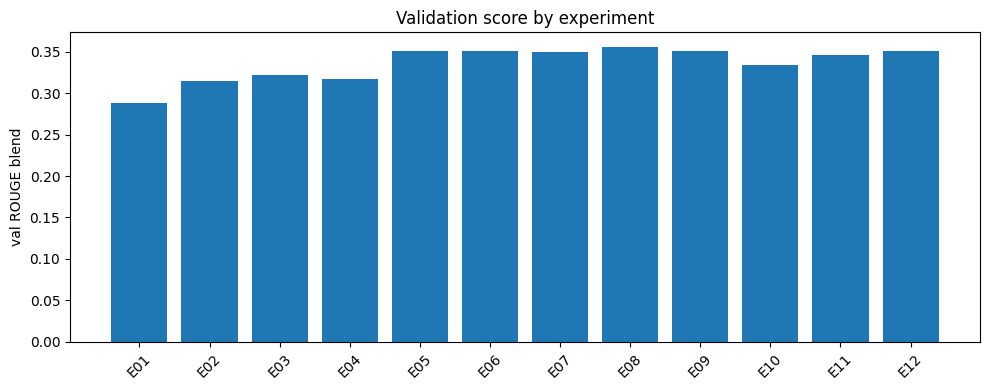

In [27]:
log = pd.read_csv(LOG_PATH)

# Validation score by experiment
plt.figure(figsize=(10,4))
plt.bar(log['exp_id'].astype(str), log['val_rouge_blend'])
plt.ylabel('val ROUGE blend'); plt.title('Validation score by experiment')
plt.xticks(rotation=45); plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'experiment_scores.png'), dpi=120); plt.show()

In [28]:
# Leaderboard progression (only rows where you filled in public_score)
pub = log.copy()
pub['public_score'] = pd.to_numeric(pub['public_score'], errors='coerce')
pub = pub.dropna(subset=['public_score'])
if len(pub):
    plt.figure(figsize=(10,4))
    plt.plot(pub['exp_id'].astype(str), pub['public_score'], marker='o')
    plt.ylabel('Zindi public score'); plt.title('Leaderboard progression')
    plt.xticks(rotation=45); plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'leaderboard_progression.png'), dpi=120); plt.show()
else:
    print('Fill the public_score column in experiment_log.csv to plot leaderboard progression.')

Fill the public_score column in experiment_log.csv to plot leaderboard progression.


  language  rouge1  rougeL
0  Aka_Gha  0.3875  0.2195
1  Amh_Eth  0.0313  0.0313
2  Eng_Eth  0.5917  0.5650
3  Eng_Gha  0.3373  0.2152
4  Eng_Ken  0.7721  0.7450
5  Eng_Uga  0.7318  0.6950
6  Lug_Uga  0.4792  0.4360
7  Swa_Ken  0.6004  0.5537


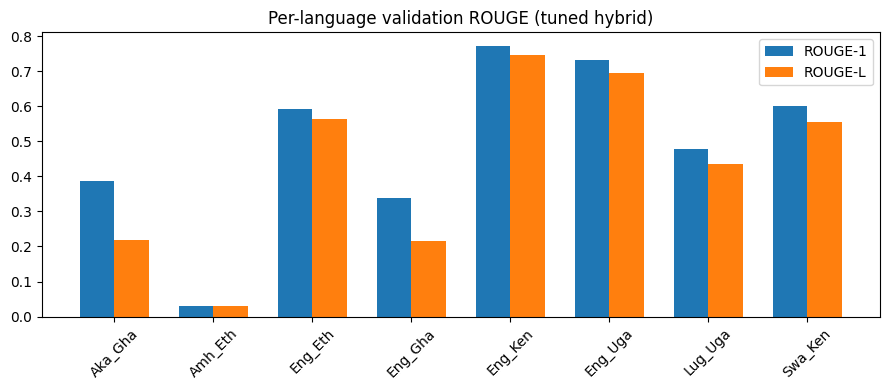

In [29]:
# Per-language validation performance of the tuned hybrid (requires best_alpha from E05)
retr = build_router(train_fit, emb_p_trainfit, alpha=0.5,
                    per_lang_alpha=best_alpha, exact_match=True)
rows = []
for lg in sorted(val['_lang'].unique()):
    m = (val['_lang'] == lg).values
    if not m.any() or ANSWER_COL not in val.columns:
        continue
    preds = route_predict(retr, val.loc[m], emb_p_val[m])
    r1, rl = rouge_eval(preds, val.loc[m, ANSWER_COL].tolist())
    rows.append({'language': lg, 'rouge1': r1, 'rougeL': rl})
perlang = pd.DataFrame(rows)
print(perlang.round(4))

x = np.arange(len(perlang)); w = 0.35
plt.figure(figsize=(9,4))
plt.bar(x - w/2, perlang['rouge1'], w, label='ROUGE-1')
plt.bar(x + w/2, perlang['rougeL'], w, label='ROUGE-L')
plt.xticks(x, perlang['language'], rotation=45); plt.legend()
plt.title('Per-language validation ROUGE (tuned hybrid)'); plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'per_language_performance.png'), dpi=120); plt.show()

## 12. Review the experiment log

Pick your two best submissions to select on Zindi. Fill the `public_score` column after each upload.

In [30]:
pd.read_csv(LOG_PATH)

,exp_id,description,val_rouge1,val_rougeL,val_rouge_blend,submission_file,public_score,config,timestamp
0,E01,TF-IDF word n-grams baseline,0.4264,0.3509,0.2876,submission_E01.csv,NaN,"{""model"": ""paraphrase-multilingual-mpnet-base-...",20260621_1445
1,E02,TF-IDF char n-grams,0.4621,0.3888,0.3148,submission_E02.csv,NaN,"{""model"": ""paraphrase-multilingual-mpnet-base-...",20260621_1446
2,E03,Semantic only,0.4704,0.3992,0.3218,submission_E03.csv,NaN,"{""model"": ""paraphrase-multilingual-mpnet-base-...",20260621_1446
3,E04,Hybrid 50/50,0.4656,0.3900,0.3166,submission_E04.csv,NaN,"{""model"": ""paraphrase-multilingual-mpnet-base-...",20260621_1447
4,E05,Per-language alpha tuning,0.5093,0.4389,0.3508,submission_E05.csv,NaN,"{""model"": ""paraphrase-multilingual-mpnet-base-...",20260621_1450
5,E06,Exact-match + per-language alpha,0.5093,0.4389,0.3508,submission_E06.csv,NaN,"{""model"": ""paraphrase-multilingual-mpnet-base-...",20260621_1450
6,E07,LaBSE backbone,0.5061,0.4380,0.3493,submission_E07.csv,NaN,"{""model"": ""LaBSE"", ""alpha"": 0.5, ""per_lang"": t...",20260621_1453
7,E08,Hybrid with char n-grams,0.5160,0.4454,0.3557,submission_E08.csv,NaN,"{""model"": ""paraphrase-multilingual-mpnet-base-...",20260621_1454
8,E09,Top-3 majority fusion,0.5091,0.4383,0.3505,submission_E09.csv,NaN,"{""model"": ""paraphrase-multilingual-mpnet-base-...",20260621_1454
9,E10,Top-3 centroid fusion,0.4876,0.4141,0.3337,submission_E10.csv,NaN,"{""model"": ""paraphrase-multilingual-mpnet-base-...",20260621_1458
